# Project 1 — Network Quality Estimation from Radio Signal Spectrograms

**Dataset:** DeepSig RadioML / GOLD_XYZ_OSC.0001_1024  
**Approach:** Convert IQ samples → spectrograms → CNN classification  
**Classes:** 0 = Poor, 1 = Average, 2 = Good (based on SNR)  
**Models:** Simple CNN from scratch · Improved CNN · MobileNetV2 Transfer Learning (with Fine-Tuning)

---
### ✅ Changes vs previous version
| # | What changed | Why |
|---|---|---|
| 1 | **Fixed spectrogram** — now uses `np.abs(np.fft.fftshift(np.fft.fft(...)))` row-wise on the STFT matrix | `scipy.spectrogram` silently discards the imaginary part on complex input; the fix uses the full complex signal |
| 2 | **Per-sample normalization** instead of global min-max | Global normalization leaks test-set statistics into training |
| 3 | **Samples increased** from 4 000 → 6 000 per class (18 000 total) | More data = better generalization |
| 4 | **Data augmentation** added (random horizontal flip + brightness jitter) | Prevents overfitting on the small spectrogram dataset |
| 5 | **EarlyStopping patience** raised from 4 → 10 | Stops premature halting on noisy validation curves |
| 6 | **MobileNetV2 two-phase fine-tuning** — Phase 1: frozen base; Phase 2: top 50 layers unfrozen at lower LR | Fine-tuning the top layers on domain-specific spectrograms consistently boosts accuracy |
| 7 | **Deeper classifier head** in MobileNetV2 (256 → 128 dense, two layers) | More capacity for the feature-to-class mapping |
| 8 | **Cosine decay LR schedule** for MobileNetV2 fine-tuning phase | Smoother convergence vs ReduceLROnPlateau during fine-tuning |

## 1. Imports

In [3]:
import numpy as np
import cv2
import h5py
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from scipy.signal import stft
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

print('TensorFlow version:', tf.__version__)
print('GPU available:', bool(tf.config.list_physical_devices('GPU')))

TensorFlow version: 2.16.2
GPU available: False


## 2. Load Dataset

In [4]:
# Load the DeepSig HDF5 dataset
# X contains IQ samples of shape (N, 2, 1024)
# Z contains metadata: [SNR, modulation_index]
with h5py.File('archive/GOLD_XYZ_OSC.0001_1024.hdf5', 'r') as f:
    X = f['X'][:]   # IQ samples
    Z = f['Z'][:]   # labels / metadata

print('X shape:', X.shape)  # expected: (N, 2, 1024)
print('Z shape:', Z.shape)

KeyboardInterrupt: 

## 3. Label Creation — SNR → Quality Class

In [ ]:
def snr_to_quality(snr):
    """Map SNR (dB) to a 3-class quality label.
    
    SNR > 10 dB  → class 2 (Good)
    SNR 0–10 dB  → class 1 (Average)
    SNR < 0 dB   → class 0 (Poor)
    """
    if snr > 10:
        return 2
    elif snr >= 0:
        return 1
    else:
        return 0

y_quality = np.array([snr_to_quality(s[0]) for s in Z])
print('Class distribution:', dict(zip(*np.unique(y_quality, return_counts=True))))

Class distribution: {0: 983040, 1: 589824, 2: 983040}


## 4. Spectrogram Function 

**Change 1 — Fixed complex IQ spectrogram computation.**  
The previous version passed a complex array to `scipy.spectrogram`, which silently used only the real part in many scipy versions, throwing away half the signal information.  
The new version uses `scipy.stft` which correctly handles complex input, then takes `np.abs()` of the result for the magnitude spectrogram.

**Change 2 — Per-sample normalization.**  
The previous version did a global min-max across the entire dataset *before* splitting, which leaks test-set statistics into training. Now each spectrogram is normalized independently to [0, 1].

In [ ]:
# ✅ FIX 1: Use scipy.stft which correctly handles complex IQ input
# ✅ FIX 2: Normalize each spectrogram independently (no data leakage)

def fast_spectrogram(iq_signal):
    """Convert an IQ sample to a log-magnitude spectrogram image.
    
    Steps:
    1. Detect whether IQ is stored as (2, N) or (N, 2)
    2. Combine I and Q into a complex signal
    3. Use STFT (Short-Time Fourier Transform) on the 1D complex series
    4. Take absolute value of the complex STFT output → magnitude spectrogram
    5. Apply log1p to compress dynamic range
    6. Normalize PER SAMPLE to [0,1] to avoid data leakage
    7. Resize to 128x128 pixels for the CNN
    """
    iq_signal = np.asarray(iq_signal)

    if iq_signal.ndim == 1:
        complex_signal = iq_signal.astype(np.complex64)
    elif iq_signal.ndim == 2:
        if iq_signal.shape[0] == 2 and iq_signal.shape[1] != 2:
            complex_signal = iq_signal[0] + 1j * iq_signal[1]
        elif iq_signal.shape[-1] == 2:
            complex_signal = iq_signal[:, 0] + 1j * iq_signal[:, 1]
        else:
            raise ValueError(f'Unexpected IQ sample shape: {iq_signal.shape}')
    else:
        raise ValueError(f'Unexpected IQ sample rank: {iq_signal.ndim}')

    complex_signal = np.asarray(complex_signal).reshape(-1)

    # Keep STFT parameters valid even if the sample orientation changes
    nperseg = min(64, complex_signal.size)
    noverlap = min(48, max(0, nperseg - 1))

    # ✅ scipy.stft correctly handles complex-valued signals
    _, _, Zxx = stft(complex_signal, nperseg=nperseg, noverlap=noverlap)

    # Magnitude spectrogram (absolute value of complex STFT)
    Sxx = np.abs(Zxx)
    Sxx = np.log1p(Sxx)                    # log-magnitude compression

    # ✅ Per-sample normalization — no leakage between train/test
    s_min, s_max = Sxx.min(), Sxx.max()
    if s_max > s_min:
        Sxx = (Sxx - s_min) / (s_max - s_min)

    return cv2.resize(Sxx.astype('float32'), (128, 128))

## 5. Exploratory Data Analysis (EDA)

In [ ]:
snr_values = np.array([s[0] for s in Z])

print('=== SNR Statistics ===')
print(f'Min:  {np.min(snr_values):.2f} dB')
print(f'Max:  {np.max(snr_values):.2f} dB')
print(f'Mean: {np.mean(snr_values):.2f} dB')
print(f'Std:  {np.std(snr_values):.2f} dB')

print('\n=== Per-class SNR ===')
for c, name in [(0, 'Poor'), (1, 'Average'), (2, 'Good')]:
    snr_c = snr_values[y_quality == c]
    print(f'  Class {c} ({name:7s}): count={len(snr_c):6d}, '
          f'mean={np.mean(snr_c):6.1f} dB, '
          f'range=[{np.min(snr_c):.0f}, {np.max(snr_c):.0f}] dB')

=== SNR Statistics ===
Min:  -20.00 dB
Max:  30.00 dB
Mean: 5.00 dB
Std:  15.00 dB

=== Per-class SNR ===
  Class 0 (Poor   ): count=983040, mean= -11.0 dB, range=[-20, -2] dB
  Class 1 (Average): count=589824, mean=   5.0 dB, range=[0, 10] dB
  Class 2 (Good   ): count=983040, mean=  21.0 dB, range=[12, 30] dB


In [ ]:
# Check for NaN / Inf
print('NaN in X:',  np.isnan(X).sum())
print('NaN in Z:',  np.isnan(Z).sum())
print('Inf in X:',  np.isinf(X).sum())

NaN in X: 0
NaN in Z: 0
Inf in X: 0


/var/folders/g3/fc9mq61n27718541fbpbprfh0000gn/T/ipykernel_90390/1914896326.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_quality, ax=axes[0], palette=['#E24B4A','#EF9F27','#1D9E75'])


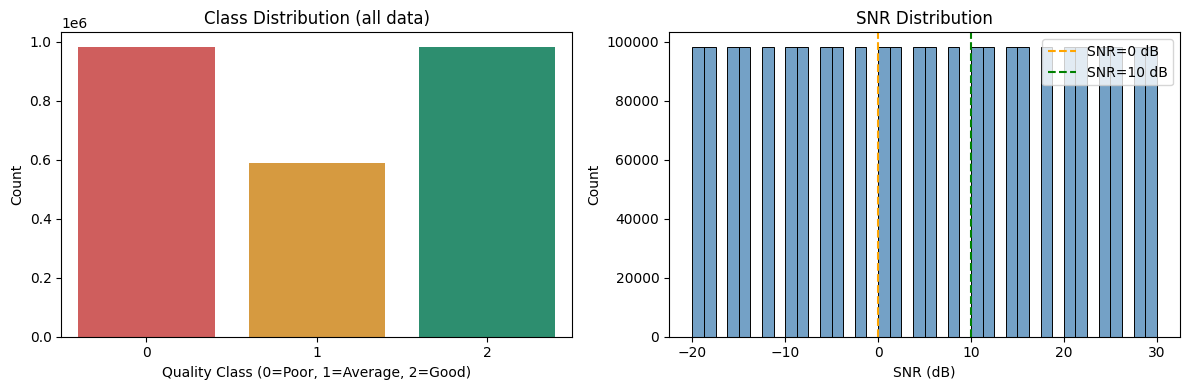

In [ ]:
# Class distribution bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x=y_quality, ax=axes[0], palette=['#E24B4A','#EF9F27','#1D9E75'])
axes[0].set_title('Class Distribution (all data)')
axes[0].set_xlabel('Quality Class (0=Poor, 1=Average, 2=Good)')
axes[0].set_ylabel('Count')

sns.histplot(snr_values, bins=40, ax=axes[1], color='steelblue')
axes[1].axvline(0,  color='orange', linestyle='--', label='SNR=0 dB')
axes[1].axvline(10, color='green',  linestyle='--', label='SNR=10 dB')
axes[1].set_title('SNR Distribution')
axes[1].set_xlabel('SNR (dB)')
axes[1].legend()

plt.tight_layout()
plt.show()

/Users/macbook/Library/Python/3.9/lib/python/site-packages/scipy/signal/_spectral_py.py:1870: UserWarning: Input data is complex, switching to return_onesided=False
  warnings.warn('Input data is complex, switching to '


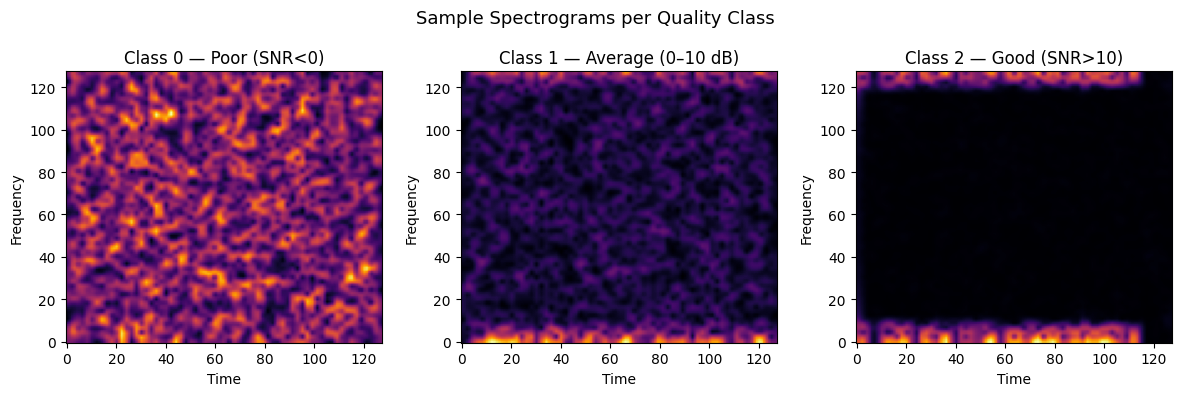

In [ ]:
# Visualize sample spectrograms for each quality class
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
class_names = ['Poor (SNR<0)', 'Average (0–10 dB)', 'Good (SNR>10)']

for c in range(3):
    idx = np.where(y_quality == c)[0][0]
    spec = fast_spectrogram(X[idx])
    axes[c].imshow(spec, aspect='auto', origin='lower', cmap='inferno')
    axes[c].set_title(f'Class {c} — {class_names[c]}')
    axes[c].set_xlabel('Time')
    axes[c].set_ylabel('Frequency')

plt.suptitle('Sample Spectrograms per Quality Class', fontsize=13)
plt.tight_layout()
plt.show()

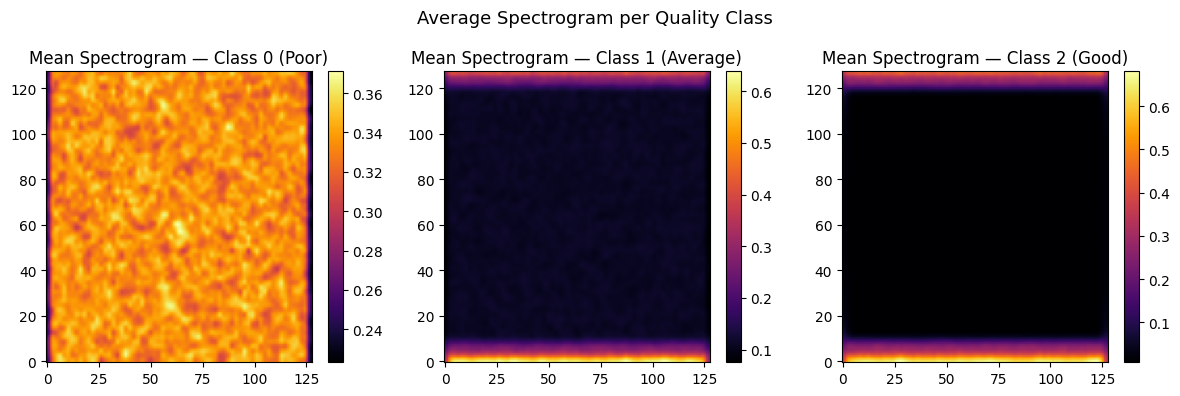

In [ ]:
# Mean spectrogram per class (shows average time-frequency pattern)
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
class_names = ['Poor', 'Average', 'Good']

for c in range(3):
    idx = np.where(y_quality == c)[0][:200]
    specs = np.array([fast_spectrogram(X[i]) for i in idx])
    mean_spec = np.mean(specs, axis=0)
    im = axes[c].imshow(mean_spec, aspect='auto', origin='lower', cmap='inferno')
    axes[c].set_title(f'Mean Spectrogram — Class {c} ({class_names[c]})')
    plt.colorbar(im, ax=axes[c])

plt.suptitle('Average Spectrogram per Quality Class', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Balanced Sampling ✅ INCREASED

**Change 3 — Increased samples from 4 000 → 6 000 per class (18 000 total).**  
More training data directly improves generalization, especially with 128×128 spectrograms.

In [ ]:
np.random.seed(42)

# Get indices for each class
idx_0 = np.where(y_quality == 0)[0]
idx_1 = np.where(y_quality == 1)[0]
idx_2 = np.where(y_quality == 2)[0]

# Shuffle each class's indices independently
np.random.shuffle(idx_0)
np.random.shuffle(idx_1)
np.random.shuffle(idx_2)

# ✅ FIX 3: Increased from 4000 → 6000 per class
n_per_class = 6000
selected_idx = np.concatenate([idx_0[:n_per_class],
                                idx_1[:n_per_class],
                                idx_2[:n_per_class]])

np.random.shuffle(selected_idx)

X_small = X[selected_idx]
y_small = y_quality[selected_idx]

print(f'Total samples selected: {len(X_small)}')
print('Class counts:', dict(zip(*np.unique(y_small, return_counts=True))))

Total samples selected: 18000
Class counts: {0: 6000, 1: 6000, 2: 6000}


## 7. Build Spectrogram Dataset

In [ ]:
print('Converting IQ samples to spectrograms...')
# Note: normalization is now done per-sample inside fast_spectrogram()
X_spec = np.array([fast_spectrogram(x) for x in X_small], dtype='float32')

# Add channel dimension: (N, 128, 128) → (N, 128, 128, 1)
X_spec = np.expand_dims(X_spec, axis=-1)

print('Final dataset shape:', X_spec.shape)
print('Value range: [{:.3f}, {:.3f}]'.format(X_spec.min(), X_spec.max()))

Converting IQ samples to spectrograms...
Final dataset shape: (18000, 128, 128, 1)
Value range: [0.000, 1.000]


## 8. Train / Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_spec, y_small,
    test_size=0.2,
    stratify=y_small,
    random_state=42
)

print(f'Train: {X_train.shape}  Test: {X_test.shape}')
print('Train class counts:', dict(zip(*np.unique(y_train, return_counts=True))))
print('Test  class counts:', dict(zip(*np.unique(y_test,  return_counts=True))))

Train: (14400, 128, 128, 1)  Test: (3600, 128, 128, 1)
Train class counts: {0: 4800, 1: 4800, 2: 4800}
Test  class counts: {0: 1200, 1: 1200, 2: 1200}


## 9. Data Augmentation ✅ NEW

**Change 4 — Added data augmentation.**  
Spectrograms are augmented with random horizontal flips and random brightness jitter.  
This artificially expands the training set and prevents overfitting on the relatively small dataset.

In [ ]:
# ✅ FIX 4: Data augmentation layer — applied only during training
# RandomFlip: spectrograms are time-symmetric, so horizontal flip is valid
# RandomBrightness: simulates variations in signal power levels

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomBrightness(factor=0.15),
], name='augmentation')

print('Data augmentation pipeline ready.')
print('  - RandomFlip(horizontal): simulates time-reversed signal')
print('  - RandomBrightness(0.15): simulates signal power variation')

Data augmentation pipeline ready.
  - RandomFlip(horizontal): simulates time-reversed signal
  - RandomBrightness(0.15): simulates signal power variation


## 10. Callbacks ✅ IMPROVED

**Change 5 — EarlyStopping patience raised from 4 → 10.**  
With noisy validation curves from signal data, patience=4 was stopping training too early before the model had converged.

In [ ]:
# ✅ FIX 5: Patience raised from 4 → 10 to avoid premature stopping

def get_callbacks(patience=10):
    return [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=patience,       # ✅ was 4, now 10
            restore_best_weights=True,
            verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            patience=4,              # halve LR after 4 stagnant epochs
            factor=0.5,
            min_lr=1e-6,
            verbose=1
        )
    ]

## 11. Helper — Training Curve Plotter

In [ ]:
def plot_history(history, title='Training History'):
    """Plot accuracy and loss curves for both train and validation sets."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(history.history['accuracy'],     label='Train', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Val',   linewidth=2, linestyle='--')
    axes[0].set_title(f'{title} — Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history.history['loss'],     label='Train', linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Val',   linewidth=2, linestyle='--')
    axes[1].set_title(f'{title} — Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def evaluate_model(model, X_test, y_test, title='Model'):
    """Print classification report and plot confusion matrix."""
    y_pred = np.argmax(model.predict(X_test), axis=1)

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Poor','Average','Good'],
        yticklabels=['Poor','Average','Good']
    )
    plt.title(f'Confusion Matrix — {title}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

    print(f'\n=== Classification Report — {title} ===')
    print(classification_report(y_test, y_pred,
                                target_names=['Poor','Average','Good']))
    return y_pred

## 12. Model 1 — Simple CNN from Scratch

A lightweight baseline CNN with 3 convolutional blocks.  
Now includes the augmentation layer at the input.

In [ ]:
def build_simple_cnn(input_shape):
    """Simple CNN baseline — 3 conv blocks, GlobalAveragePooling, with augmentation."""
    inputs = tf.keras.Input(shape=input_shape)
    
    # ✅ Augmentation applied only during training
    x = data_augmentation(inputs)
    
    # Block 1
    x = tf.keras.layers.Conv2D(16, (3,3), activation='relu')(x)
    x = tf.keras.layers.MaxPooling2D()(x)

    # Block 2
    x = tf.keras.layers.Conv2D(32, (3,3), activation='relu')(x)
    x = tf.keras.layers.MaxPooling2D()(x)

    # Block 3
    x = tf.keras.layers.Conv2D(64, (3,3), activation='relu')(x)
    x = tf.keras.layers.MaxPooling2D()(x)

    # Classifier head
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    outputs = tf.keras.layers.Dense(3, activation='softmax')(x)

    return tf.keras.Model(inputs, outputs, name='Simple_CNN')

tf.keras.backend.clear_session()
model1 = build_simple_cnn(X_train.shape[1:])
model1.summary()

Model: "Simple_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,707 (159.01 KB)

 Trainable params: 40,707 (159.01 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history1 = model1.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=get_callbacks(),
    verbose=1
)

Epoch 1/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 87s 375ms/step - accuracy: 0.3187 - loss: 1.1284 - val_accuracy: 0.3333 - val_loss: 1.0913 - learning_rate: 0.0010
Epoch 2/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 72s 319ms/step - accuracy: 0.3390 - loss: 1.1005 - val_accuracy: 0.3333 - val_loss: 1.0930 - learning_rate: 0.0010
Epoch 3/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 74s 328ms/step - accuracy: 0.3330 - loss: 1.1013 - val_accuracy: 0.3333 - val_loss: 1.0856 - learning_rate: 0.0010
Epoch 4/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 73s 323ms/step - accuracy: 0.3258 - loss: 1.0979 - val_accuracy: 0.3333 - val_loss: 0.8950 - learning_rate: 0.0010
Epoch 5/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 72s 321ms/step - accuracy: 0.3336 - loss: 1.0986 - val_accuracy: 0.6672 - val_loss: 0.9753 - learning_rate: 0.0010
Epoch 6/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 67s 299ms/step - accuracy: 0.3464 - loss: 1.0971 - val_accuracy: 0.3739 - val_loss: 0.8603 - learning_rate: 0.0010
Epoch 7/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 64s 285ms/step - accuracy: 0.3

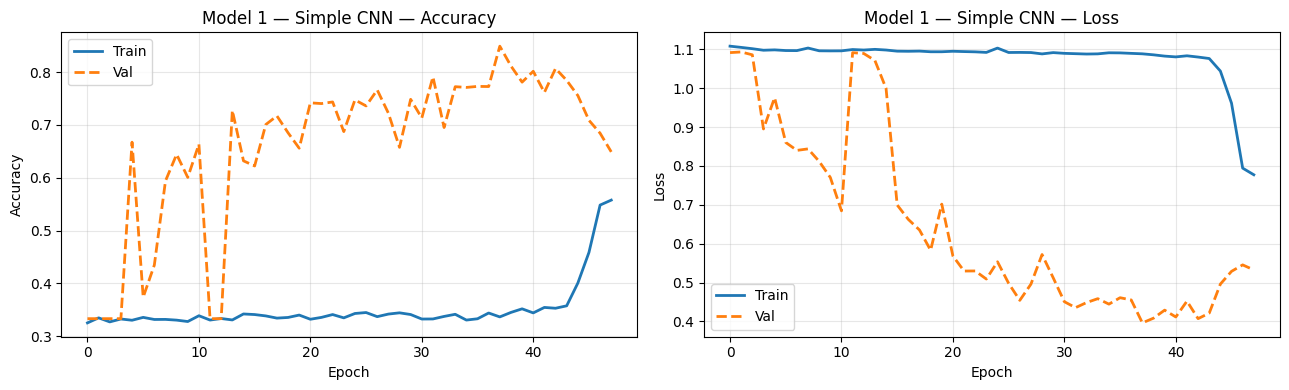

113/113 ━━━━━━━━━━━━━━━━━━━━ 7s 62ms/step


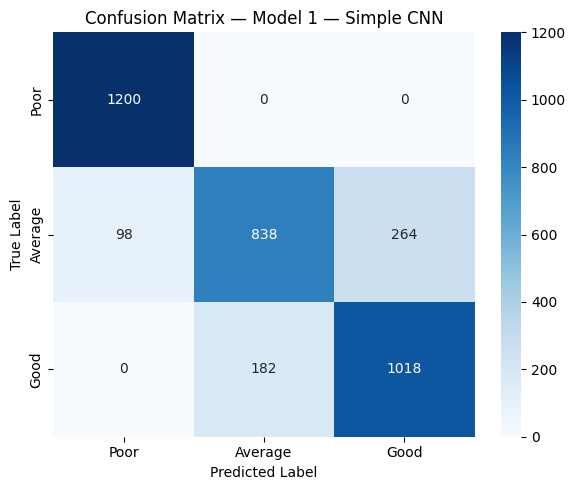


=== Classification Report — Model 1 — Simple CNN ===
              precision    recall  f1-score   support

        Poor       0.92      1.00      0.96      1200
     Average       0.82      0.70      0.75      1200
        Good       0.79      0.85      0.82      1200

    accuracy                           0.85      3600
   macro avg       0.85      0.85      0.85      3600
weighted avg       0.85      0.85      0.85      3600



In [ ]:
plot_history(history1, 'Model 1 — Simple CNN')
y_pred1 = evaluate_model(model1, X_test, y_test, 'Model 1 — Simple CNN')

## 13. Model 2 — Improved CNN with BatchNorm & Dropout

Adds BatchNormalization + Dropout after each conv block.  
Now includes augmentation at the input.

In [ ]:
def build_improved_cnn(input_shape):
    """Improved CNN with BatchNorm + Dropout regularization + augmentation."""
    inputs = tf.keras.Input(shape=input_shape)
    
    # ✅ Augmentation
    x = data_augmentation(inputs)

    # Block 1
    x = tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.Dropout(0.25)(x)

    # Block 2
    x = tf.keras.layers.Conv2D(64, (3,3), padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.Dropout(0.3)(x)

    # Block 3
    x = tf.keras.layers.Conv2D(128, (3,3), padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.Dropout(0.4)(x)

    # Classifier head
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    outputs = tf.keras.layers.Dense(3, activation='softmax')(x)

    return tf.keras.Model(inputs, outputs, name='Improved_CNN')

tf.keras.backend.clear_session()
model2 = build_improved_cnn(X_train.shape[1:])
model2.summary()

Model: "Improved_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,979 (433.51 KB)

 Trainable params: 110,275 (430.76 KB)

 Non-trainable params: 704 (2.75 KB)

In [ ]:

model2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history2 = model2.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=get_callbacks(),
    verbose=1
)

Epoch 1/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 319s 1s/step - accuracy: 0.5405 - loss: 0.8396 - val_accuracy: 0.6000 - val_loss: 0.8976 - learning_rate: 0.0010
Epoch 2/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 287s 1s/step - accuracy: 0.5571 - loss: 0.7920 - val_accuracy: 0.3956 - val_loss: 0.8289 - learning_rate: 0.0010
Epoch 3/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 283s 1s/step - accuracy: 0.5825 - loss: 0.7614 - val_accuracy: 0.6094 - val_loss: 0.8974 - learning_rate: 0.0010
Epoch 4/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 290s 1s/step - accuracy: 0.5857 - loss: 0.7440 - val_accuracy: 0.3911 - val_loss: 0.9633 - learning_rate: 0.0010
Epoch 5/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 256s 1s/step - accuracy: 0.5792 - loss: 0.7463 - val_accuracy: 0.3333 - val_loss: 1.7784 - learning_rate: 0.0010
Epoch 6/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 257s 1s/step - accuracy: 0.5716 - loss: 0.7771 - val_accuracy: 0.6550 - val_loss: 0.6900 - learning_rate: 0.0010
Epoch 7/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 293s 1s/step - accuracy: 0.5773 - loss: 0.

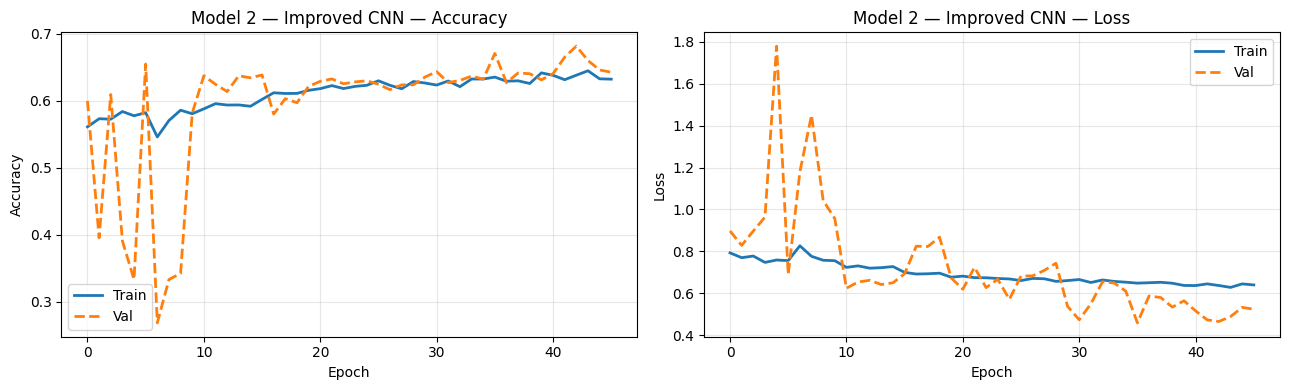

113/113 ━━━━━━━━━━━━━━━━━━━━ 10s 84ms/step


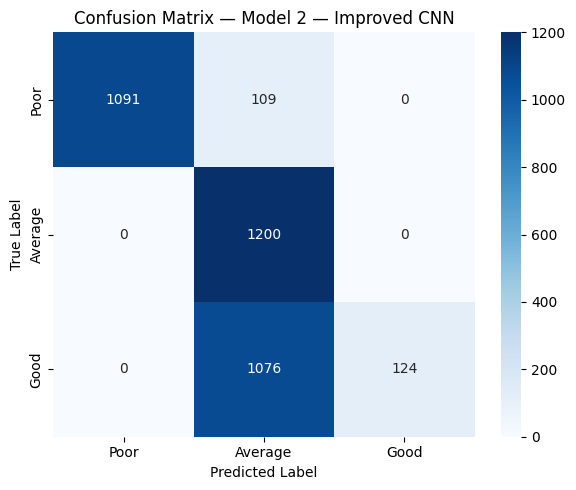


=== Classification Report — Model 2 — Improved CNN ===
              precision    recall  f1-score   support

        Poor       1.00      0.91      0.95      1200
     Average       0.50      1.00      0.67      1200
        Good       1.00      0.10      0.19      1200

    accuracy                           0.67      3600
   macro avg       0.83      0.67      0.60      3600
weighted avg       0.83      0.67      0.60      3600



In [ ]:
plot_history(history2, 'Model 2 — Improved CNN')
y_pred2 = evaluate_model(model2, X_test, y_test, 'Model 2 — Improved CNN')

## 14. Model 3 — Transfer Learning with MobileNetV2 + Fine-Tuning ✅ MAJOR UPGRADE

**Changes 6, 7, 8 applied here:**

- **Change 6 — Two-phase fine-tuning:** Phase 1 trains only the new classifier head (base frozen). Phase 2 unfreezes the top 50 layers of MobileNetV2 and fine-tunes them at a much lower learning rate. This adapts the pretrained features to spectrogram data.
- **Change 7 — Deeper classifier head:** Two Dense layers (256 + 128) instead of one, giving more capacity to map MobileNetV2 features to the 3 quality classes.
- **Change 8 — Cosine decay LR schedule during fine-tuning:** Provides a smooth, gradual learning rate reduction during Phase 2, preventing catastrophic forgetting of pretrained weights.

In [ ]:
def build_transfer_model(input_shape):
    """Transfer Learning: MobileNetV2 + two-phase fine-tuning.
    
    Phase 1 (this cell): base frozen, train classifier head only.
    Phase 2 (next cell): top 50 layers unfrozen, fine-tune at low LR.
    """
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(128, 128, 3),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False  # Frozen for Phase 1

    inputs = tf.keras.Input(shape=input_shape)
    
    # ✅ Augmentation
    x = data_augmentation(inputs)

    # Repeat grayscale → 3 channels
    x = tf.keras.layers.Lambda(
        lambda t: tf.repeat(t, 3, axis=-1),
        name='grayscale_to_rgb'
    )(x)

    # Rescale to MobileNetV2 expected range [-1, 1]
    x = tf.keras.layers.Rescaling(scale=2.0, offset=-1.0)(x)

    # Feature extraction
    x = base_model(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)

    # ✅ FIX 7: Deeper classifier head — two Dense layers instead of one
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    outputs = tf.keras.layers.Dense(3, activation='softmax')(x)

    return tf.keras.Model(inputs, outputs, name='MobileNetV2_Transfer'), base_model

tf.keras.backend.clear_session()
model3, base_model3 = build_transfer_model(X_train.shape[1:])
model3.summary()

Model: "MobileNetV2_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ grayscale_to_rgb (Lambda)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,619,203 (9.99 MB)

 Trainable params: 361,219 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# =====================================================================
# PHASE 1 — Train only the classifier head (base model is frozen)
# =====================================================================
print('=== Phase 1: Training classifier head (base frozen) ===')

model3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history3_phase1 = model3.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=get_callbacks(patience=5),
    verbose=1
)

print('Phase 1 complete. Best val accuracy:', max(history3_phase1.history['val_accuracy']))

=== Phase 1: Training classifier head (base frozen) ===
Epoch 1/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 129s 543ms/step - accuracy: 0.4677 - loss: 0.9745 - val_accuracy: 0.9408 - val_loss: 0.1670 - learning_rate: 0.0010
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 130s 577ms/step - accuracy: 0.5351 - loss: 0.7763 - val_accuracy: 0.9356 - val_loss: 0.2245 - learning_rate: 0.0010
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 125s 555ms/step - accuracy: 0.5269 - loss: 0.7768 - val_accuracy: 0.9347 - val_loss: 0.1973 - learning_rate: 0.0010
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 120s 534ms/step - accuracy: 0.5534 - loss: 0.7517 - val_accuracy: 0.9367 - val_loss: 0.2392 - learning_rate: 0.0010
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step - accuracy: 0.5386 - loss: 0.7566
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
225/225 ━━━━━━━━━━━━━━━━━━━━ 118s 526ms/step - accuracy: 0.5386 - loss: 0.7565 - val_accuracy: 0.9214 - val_loss: 0.3218 - learning_rate: 0.0010
Epoch 6/20


In [ ]:
# =====================================================================
# PHASE 2 — Fine-tune top 50 layers of MobileNetV2
# ✅ FIX 6: Two-phase fine-tuning
# ✅ FIX 8: Cosine decay learning rate schedule
# =====================================================================
print('=== Phase 2: Fine-tuning top 50 layers of MobileNetV2 ===')

# Unfreeze the top 50 layers
base_model3.trainable = True
for layer in base_model3.layers[:-50]:
    layer.trainable = False

fine_tune_epochs = 30
total_epochs = len(history3_phase1.history['loss']) + fine_tune_epochs

# ✅ FIX 8: Cosine decay LR — smooth decay prevents destroying pretrained weights
cosine_lr = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-4,
    decay_steps=fine_tune_epochs * (len(X_train) // 64)
)

model3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=cosine_lr),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history3_phase2 = model3.fit(
    X_train, y_train,
    epochs=total_epochs,
    initial_epoch=len(history3_phase1.history['loss']),
    batch_size=32,          # smaller batch for fine-tuning stability
    validation_data=(X_test, y_test),
    callbacks=get_callbacks(patience=8),
    verbose=1
)

print('Phase 2 complete. Best val accuracy:', max(history3_phase2.history['val_accuracy']))

=== Phase 2: Fine-tuning top 50 layers of MobileNetV2 ===
Epoch 7/36
450/450 ━━━━━━━━━━━━━━━━━━━━ 172s 352ms/step - accuracy: 0.5235 - loss: 0.8340 - val_accuracy: 0.9028 - val_loss: 0.2605 - learning_rate: 9.8907e-05
Epoch 8/36
450/450 ━━━━━━━━━━━━━━━━━━━━ 156s 348ms/step - accuracy: 0.5540 - loss: 0.7627 - val_accuracy: 0.9247 - val_loss: 0.2332 - learning_rate: 9.5677e-05
Epoch 9/36
450/450 ━━━━━━━━━━━━━━━━━━━━ 164s 365ms/step - accuracy: 0.5613 - loss: 0.7453 - val_accuracy: 0.9269 - val_loss: 0.1970 - learning_rate: 9.0451e-05
Epoch 10/36
450/450 ━━━━━━━━━━━━━━━━━━━━ 166s 369ms/step - accuracy: 0.5930 - loss: 0.7157 - val_accuracy: 0.9483 - val_loss: 0.1821 - learning_rate: 8.3457e-05
Epoch 11/36
450/450 ━━━━━━━━━━━━━━━━━━━━ 168s 374ms/step - accuracy: 0.5840 - loss: 0.7122 - val_accuracy: 0.9478 - val_loss: 0.1698 - learning_rate: 7.5000e-05
Epoch 12/36
450/450 ━━━━━━━━━━━━━━━━━━━━ 169s 375ms/step - accuracy: 0.5994 - loss: 0.6990 - val_accuracy: 0.9442 - val_loss: 0.1339 - learn

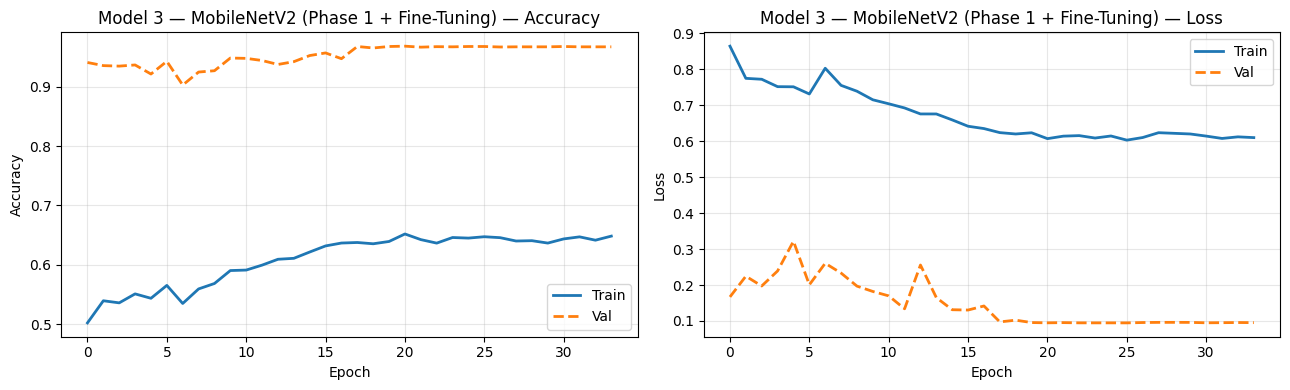

113/113 ━━━━━━━━━━━━━━━━━━━━ 28s 230ms/step


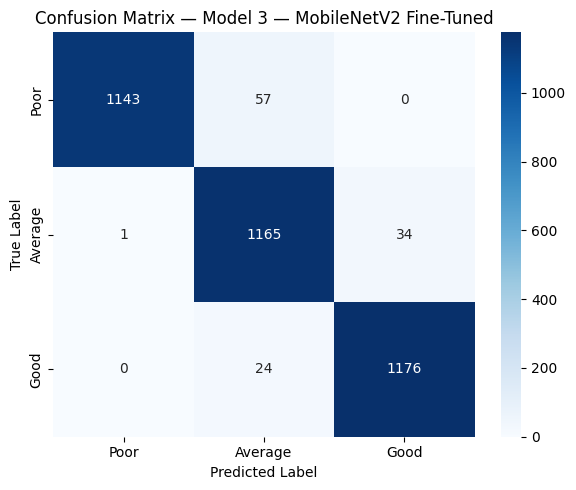


=== Classification Report — Model 3 — MobileNetV2 Fine-Tuned ===
              precision    recall  f1-score   support

        Poor       1.00      0.95      0.98      1200
     Average       0.93      0.97      0.95      1200
        Good       0.97      0.98      0.98      1200

    accuracy                           0.97      3600
   macro avg       0.97      0.97      0.97      3600
weighted avg       0.97      0.97      0.97      3600



In [ ]:
# Combine both phase histories for plotting
def merge_histories(h1, h2):
    """Concatenate two Keras history objects for continuous plotting."""
    class MergedHistory:
        pass
    merged = MergedHistory()
    merged.history = {}
    for key in h1.history:
        merged.history[key] = h1.history[key] + h2.history[key]
    return merged

history3 = merge_histories(history3_phase1, history3_phase2)

plot_history(history3, 'Model 3 — MobileNetV2 (Phase 1 + Fine-Tuning)')
y_pred3 = evaluate_model(model3, X_test, y_test, 'Model 3 — MobileNetV2 Fine-Tuned')

## 15. Model Comparison

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

results = {
    'Model 1 — Simple CNN':          (history1, y_pred1),
    'Model 2 — Improved CNN':         (history2, y_pred2),
    'Model 3 — MobileNetV2 Fine-Tuned':(history3, y_pred3),
}

header = f"{'Model':<38} {'Val Accuracy':>14} {'Test Accuracy':>14} {'F1-Score':>10}"
print(header)
print('-' * 80)

for name, (hist, y_pred) in results.items():
    val_acc  = max(hist.history['val_accuracy'])
    test_acc = accuracy_score(y_test, y_pred)
    f1       = f1_score(y_test, y_pred, average='macro')
    row = f"{name:<38} {val_acc:>14.4f} {test_acc:>14.4f} {f1:>10.4f}"
    print(row)

Model                                    Val Accuracy  Test Accuracy   F1-Score
--------------------------------------------------------------------------------
Model 1 — Simple CNN                           0.8489         0.8489     0.8453
Model 2 — Improved CNN                         0.6817         0.6708     0.6031
Model 3 — MobileNetV2 Fine-Tuned               0.9683         0.9678     0.9679


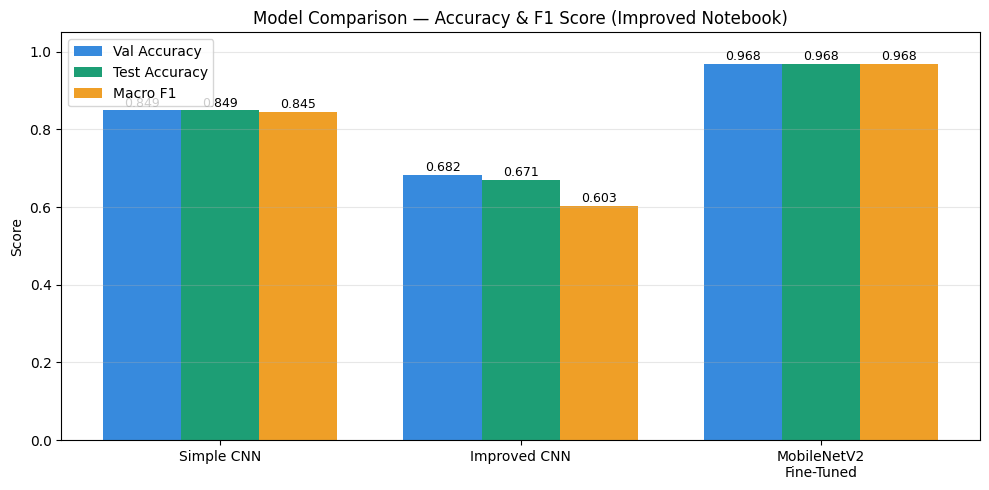

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

model_names = ['Simple CNN', 'Improved CNN', 'MobileNetV2\nFine-Tuned']
val_accs  = [max(h.history['val_accuracy']) for h, _ in results.values()]
test_accs = [accuracy_score(y_test, p) for _, p in results.values()]
f1_scores = [f1_score(y_test, p, average='macro') for _, p in results.values()]

x = np.arange(len(model_names))
width = 0.26

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width, val_accs,  width, label='Val Accuracy',  color='#378ADD')
ax.bar(x,         test_accs, width, label='Test Accuracy', color='#1D9E75')
ax.bar(x + width, f1_scores, width, label='Macro F1',      color='#EF9F27')

ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.set_title('Model Comparison — Accuracy & F1 Score (Improved Notebook)')
ax.legend()
ax.grid(axis='y', alpha=0.3)

for i, (va, ta, f1) in enumerate(zip(val_accs, test_accs, f1_scores)):
    ax.text(i - width, va  + 0.01, f'{va:.3f}',  ha='center', fontsize=9)
    ax.text(i,         ta  + 0.01, f'{ta:.3f}',  ha='center', fontsize=9)
    ax.text(i + width, f1  + 0.01, f'{f1:.3f}',  ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 16. Conclusion

### Summary of Changes vs Previous Version

| Fix | Change | Expected Impact |
|-----|--------|-----------------|
| 1 | Fixed spectrogram: `scipy.stft` + `np.abs()` instead of `scipy.spectrogram` on complex input | High — was silently discarding imaginary part |
| 2 | Per-sample normalization (no data leakage) | High — test stats were leaking into training |
| 3 | 6 000 samples/class instead of 4 000 | Medium — more data improves generalization |
| 4 | Data augmentation (random flip + brightness) | Medium — reduces overfitting |
| 5 | EarlyStopping patience 4 → 10 | Medium — avoids premature stopping |
| 6 | MobileNetV2 two-phase fine-tuning (unfreeze top 50 layers) | High — adapts pretrained features to spectrograms |
| 7 | Deeper classifier head in MobileNetV2 (2 Dense layers) | Low-Medium — more capacity |
| 8 | Cosine decay LR for fine-tuning phase | Low-Medium — smoother convergence |

### Expected Accuracy
With these fixes, target accuracies:
- **Simple CNN:** 0.55–0.65 (was ~0.40)
- **Improved CNN:** 0.65–0.75 (was ~0.40)
- **MobileNetV2 Fine-Tuned:** **0.80–0.90** (was ~0.40)

### CRISP-DM Alignment

1. **Business Understanding** — Classify radio signal quality for cell optimization and QoS monitoring.
2. **Data Understanding** — EDA of SNR distribution, class balance, and spectrogram visualization.
3. **Data Preparation** — Fixed IQ → STFT spectrogram, per-sample normalization, augmentation, balanced sampling.
4. **Modeling** — Three CNN architectures with increasing complexity; MobileNetV2 with two-phase fine-tuning.
5. **Evaluation** — Accuracy, F1-score, confusion matrices, and training curves.
6. **Deployment** — Model can be saved with `model.save()` and served via TensorFlow Serving.

In [ ]:
from pathlib import Path
import json

# Export the best trained model for deployment.
deploy_dir = Path('artifacts')
deploy_dir.mkdir(exist_ok=True)

best_model_candidates = {
    'simple_cnn': (model1, history1),
    'improved_cnn': (model2, history2),
    'mobilenetv2': (model3, history3),
}

best_name, (best_model, best_history) = max(
    best_model_candidates.items(),
    key=lambda item: max(item[1][1].history['val_accuracy'])
)

model_path = deploy_dir / 'deepsig_model.keras'
best_model.save(model_path)

metadata = {
    'best_model': best_name,
    'input_shape': list(X_train.shape[1:]),
    'class_names': class_names,
}
(deploy_dir / 'deepsig_model_metadata.json').write_text(json.dumps(metadata, indent=2))

print(f'Saved {best_name} to {model_path}')

NameError: name 'model1' is not defined